<a href="https://colab.research.google.com/github/parkerim/breast-cancer-classification-pipeline/blob/main/model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score

df = pd.read_csv('data.csv')

# 1. Data Clean

df_clean = df.drop(columns=['id',"Unnamed: 32"])
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# 2.Train and Test Split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify = y)
# 3. Custom Transformer

class CellularFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
            X_copy = X.copy()
            X_copy['radius_anomaly_ratio'] = X_copy['radius_worst'] / X_copy['radius_mean']
            X_copy['shape_irregularity'] = (X_copy['perimeter_mean'] ** 2) / X_copy['area_mean']
            return X_copy

# 4. PIPELINE
rf_pipeline = Pipeline(steps=[
    ('feature_engineering', CellularFeatureEngineer()),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
# 5. Training & Prediction
rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

# Result
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9737


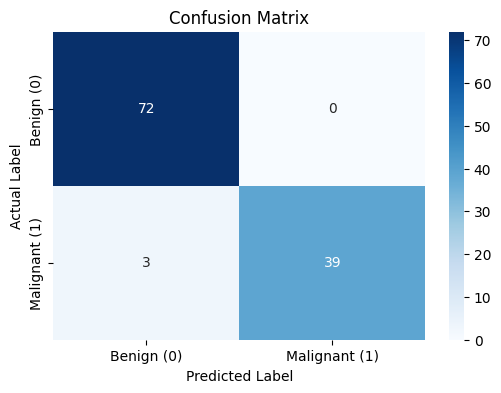

Classification Report:

               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Modelin Test Seti üzerindeki tahminleri
y_pred = rf_pipeline.predict(X_test)

# 1. Confusion Matrix Calculation
cm = confusion_matrix(y_test, y_pred)

# 2. Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))